# Installing & Importing Libraries

In [27]:
pip install pandas numpy matplotlib seaborn missingno

Note: you may need to restart the kernel to use updated packages.


In [28]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import missingno as msno


In [29]:
pd.set_option('display.width', None)          # let it use full available width
pd.set_option('display.max_columns', None)    # show all columns, don't truncate
pd.set_option('display.expand_frame_repr', False)  # this is the key one — stops the "\" wrap-around

## Load Dataset

In [30]:
df = pd.read_csv('Airbnb.csv')

## Initial understanding of its structure and content.

In [31]:
df.head(20)

,id,name,host_id,host_name,neighbourhood group,neighbourhood,latitude,longitude,room type,price,minimum nights,number_of_reviews,last review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1.0,9,10/19/2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1.0,45,5/21/2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3.0,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1.0,270,7/5/2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10.0,9,11/19/2018,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200.0,3.0,74,6/22/2019,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60.0,45.0,49,10/5/2017,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79.0,2.0,430,6/24/2019,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79.0,2.0,118,7/21/2017,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150.0,1.0,160,6/9/2019,1.33,4,188


In [32]:
df.tail()

,id,name,host_id,host_name,neighbourhood group,neighbourhood,latitude,longitude,room type,price,minimum nights,number_of_reviews,last review,reviews_per_month,calculated_host_listings_count,availability_365
48895,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70.0,2.0,0,NaN,NaN,2,9
48896,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40.0,4.0,0,NaN,NaN,2,36
48897,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115.0,10.0,0,NaN,NaN,1,27
48898,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55.0,1.0,0,NaN,NaN,6,2
48899,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90.0,7.0,0,NaN,NaN,1,23


## Shape of the dataset

In [33]:
df.shape

(48900, 16)

## Replace spaces in column labels with underscores for consistency

In [34]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood group',
       'neighbourhood', 'latitude', 'longitude', 'room type', 'price',
       'minimum nights', 'number_of_reviews', 'last review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [35]:
df.columns = df.columns.str.replace(' ', '_')

In [36]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

## Check the data types of each attribute

In [37]:
df.info()
df.neighbourhood_group.unique()

<class 'pandas.DataFrame'>
RangeIndex: 48900 entries, 0 to 48899
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48900 non-null  int64  
 1   name                            48884 non-null  str    
 2   host_id                         48900 non-null  int64  
 3   host_name                       48879 non-null  str    
 4   neighbourhood_group             48900 non-null  str    
 5   neighbourhood                   48900 non-null  str    
 6   latitude                        48900 non-null  float64
 7   longitude                       48900 non-null  float64
 8   room_type                       48900 non-null  str    
 9   price                           48900 non-null  float64
 10  minimum_nights                  48900 non-null  float64
 11  number_of_reviews               48900 non-null  int64  
 12  last_review                     38848 non-n

<StringArray>
['Brooklyn', 'Manhattan', 'Broklyn', 'Queens', 'Staten Island', 'Bronx']
Length: 6, dtype: str

Mentioned minimum nights and price was float but they should be in int or whole number for better understanding. Similarly reviews per month should also be in int becaue reviews can't be 1.5 or 2.8 etc. 

## Convert the minimum_nights and price columns from float to integer after removing any non-numeric characters such as currency symbols.

In [38]:
# Round to nearest whole number, then cast to nullable integer
df['price'] = pd.to_numeric(df['price'], errors='coerce').round().astype('Int64')
df.price

0        149
1        225
2        150
3         89
4         80
        ... 
48895     70
48896     40
48897    115
48898     55
48899     90
Name: price, Length: 48900, dtype: Int64

In [39]:
# Round to nearest whole number, then cast to nullable integer
df['minimum_nights'] = pd.to_numeric(df['minimum_nights'], errors='coerce').round().astype('Int64')
df.minimum_nights

0         1
1         1
2         3
3         1
4        10
         ..
48895     2
48896     4
48897    10
48898     1
48899     7
Name: minimum_nights, Length: 48900, dtype: Int64

## Share the information of the dataset. What is its importance in EDA?
The dataset contains the information of listings on Airbnb with almost 48900 rows and 16 features. After doing EDA, these features helps us to understand which type of location, appartment type or prices and availability will be suitable to easily rent out our apartment.

## Summary statistics for numerical columns.

In [40]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.890000e+04,4.890000e+04,48900.000000,48900.000000,48900.0,48900.0,48900.000000,38848.000000,48900.000000,48900.000000
mean,1.901520e+07,6.761310e+07,40.728949,-73.952172,152.720552,7.032209,23.279693,1.373126,7.143374,112.783742
std,1.098423e+07,7.860992e+07,0.054529,0.046155,240.142697,20.51376,44.555777,1.680367,32.950889,131.626347
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.0,1.0,0.000000,0.010000,1.000000,0.000000
25%,9.470353e+06,7.812758e+06,40.690100,-73.983072,69.0,1.0,1.000000,0.190000,1.000000,0.000000
50%,1.967620e+07,3.079058e+07,40.723075,-73.955680,106.0,3.0,5.000000,0.720000,1.000000,45.000000
75%,2.915173e+07,1.074344e+08,40.763112,-73.936280,175.0,5.0,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.0,1250.0,629.000000,58.500000,327.000000,365.000000


1. The mean and 50 % of price have significant differnce and the 75% and max also have significant differece. This shows that the price feature have some sort of outliers but we can confirm it later with visualization and other methods.
2. Minimum_nights and number_of_reviews have also same problem as above and also have 1250 max value which was not possible. So we can also check this unusuality.
3. The entries of reviews_per_month was looking stable, the only problem was outliers which we can confirm from visualization. Also the count shows almost 10k entries are missing like 20% of data which we have to impute if possible.
4. Price has a minimum of $0.00 which is unrealistic.
5. High variability across several columns (std > or ≈ mean)
6. Calculated_host_listings_count — max of 327 ( this might be a commercial_host)
7. availability_365 has a minimum of 0 correlates with min of number of reviews and reviews per month, this might be indication of dead or inactive listings.

## Summary statistics for Categorical columns.

In [41]:
print(df.describe(include='object'))

                  name host_name neighbourhood_group neighbourhood        room_type last_review
count            48884     48879               48900         48900            48900       38848
unique           47896     11452                   6           221                3        1764
top     Hillside Hotel   Michael           Manhattan  Williamsburg  Entire home/apt   6/23/2019
freq                18       417               21664          3920            25413        1413


C:\Users\Dell\AppData\Local\Temp\ipykernel_9628\3781773561.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


1. name — 16 missing values
2. host_name — extreme repetition (potential aggregator/agency, not a real "name")
3. name — "Hillside Hotel" appearing 18 times
4. neighbourhood — high concentration in Williamsburg
5. neighbourhood_group — Manhattan dominance

## Identify duplicate rows and remove them to ensure data integrity.

In [42]:
exact_dupes = df[df.duplicated(keep=False)]
print(f"Exact duplicate rows found: {df.duplicated().sum()}")
print(exact_dupes)

Exact duplicate rows found: 5
      id                               name  host_id host_name neighbourhood_group       neighbourhood  latitude  longitude        room_type  price  minimum_nights  number_of_reviews last_review  reviews_per_month  calculated_host_listings_count  availability_365
1   2595              Skylit Midtown Castle     2845  Jennifer           Manhattan             Midtown  40.75362  -73.98377  Entire home/apt    225               1                 45   5/21/2019               0.38                               2               355
6   5121                    BlissArtsSpace!     7356     Garon            Brooklyn  Bedford-Stuyvesant  40.68688  -73.95596     Private room     60              45                 49   10/5/2017               0.40                               1                 0
10  5295   Beautiful 1br on Upper West Side     7702      Lena           Manhattan     Upper West Side  40.80316  -73.96545  Entire home/apt    135               5               

In [43]:
df = df.drop_duplicates(keep='first')
print(f"Shape after removing exact duplicates: {df.shape}")

Shape after removing exact duplicates: (48895, 16)


## Checking missing values and their pattern.

In [44]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

<Axes: >

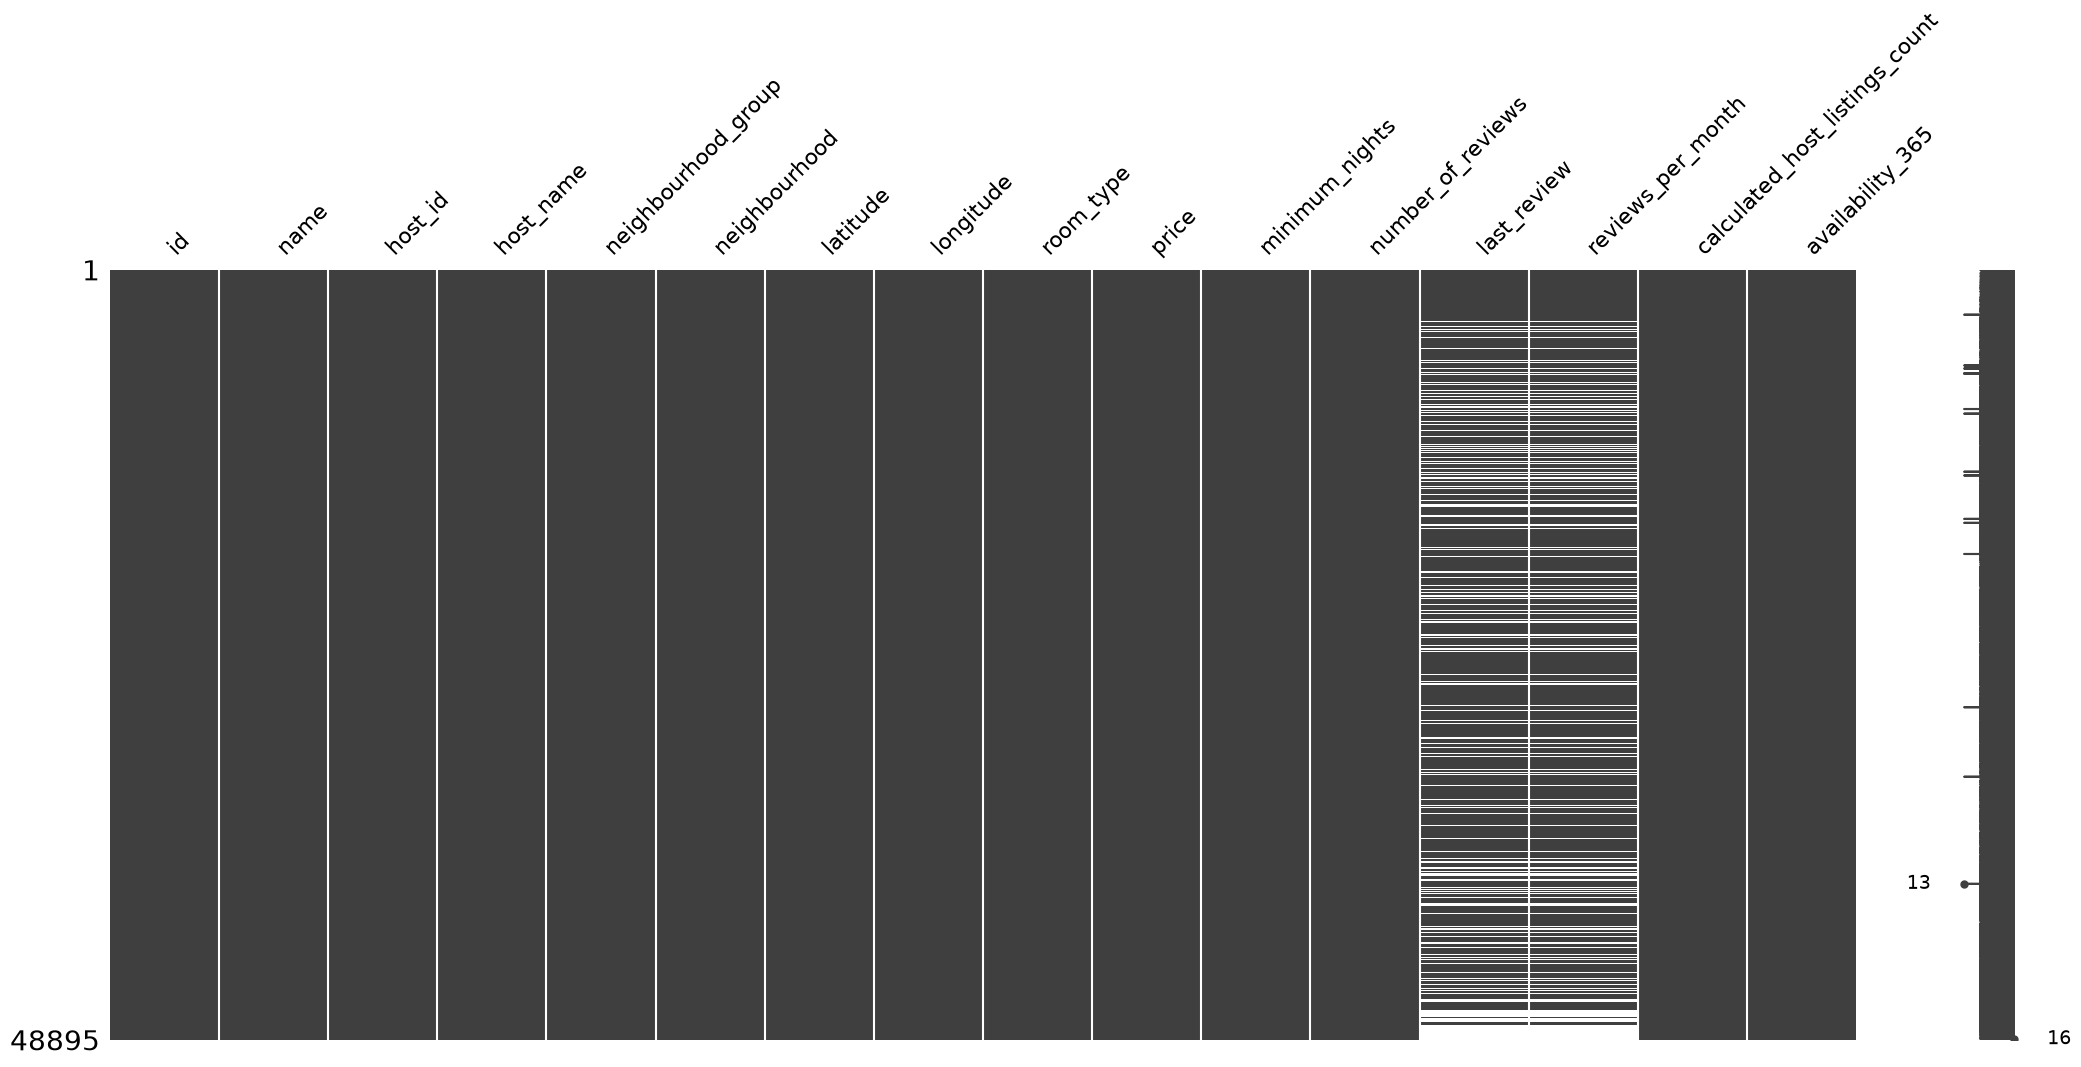

In [45]:
msno.matrix(df)

<Axes: >

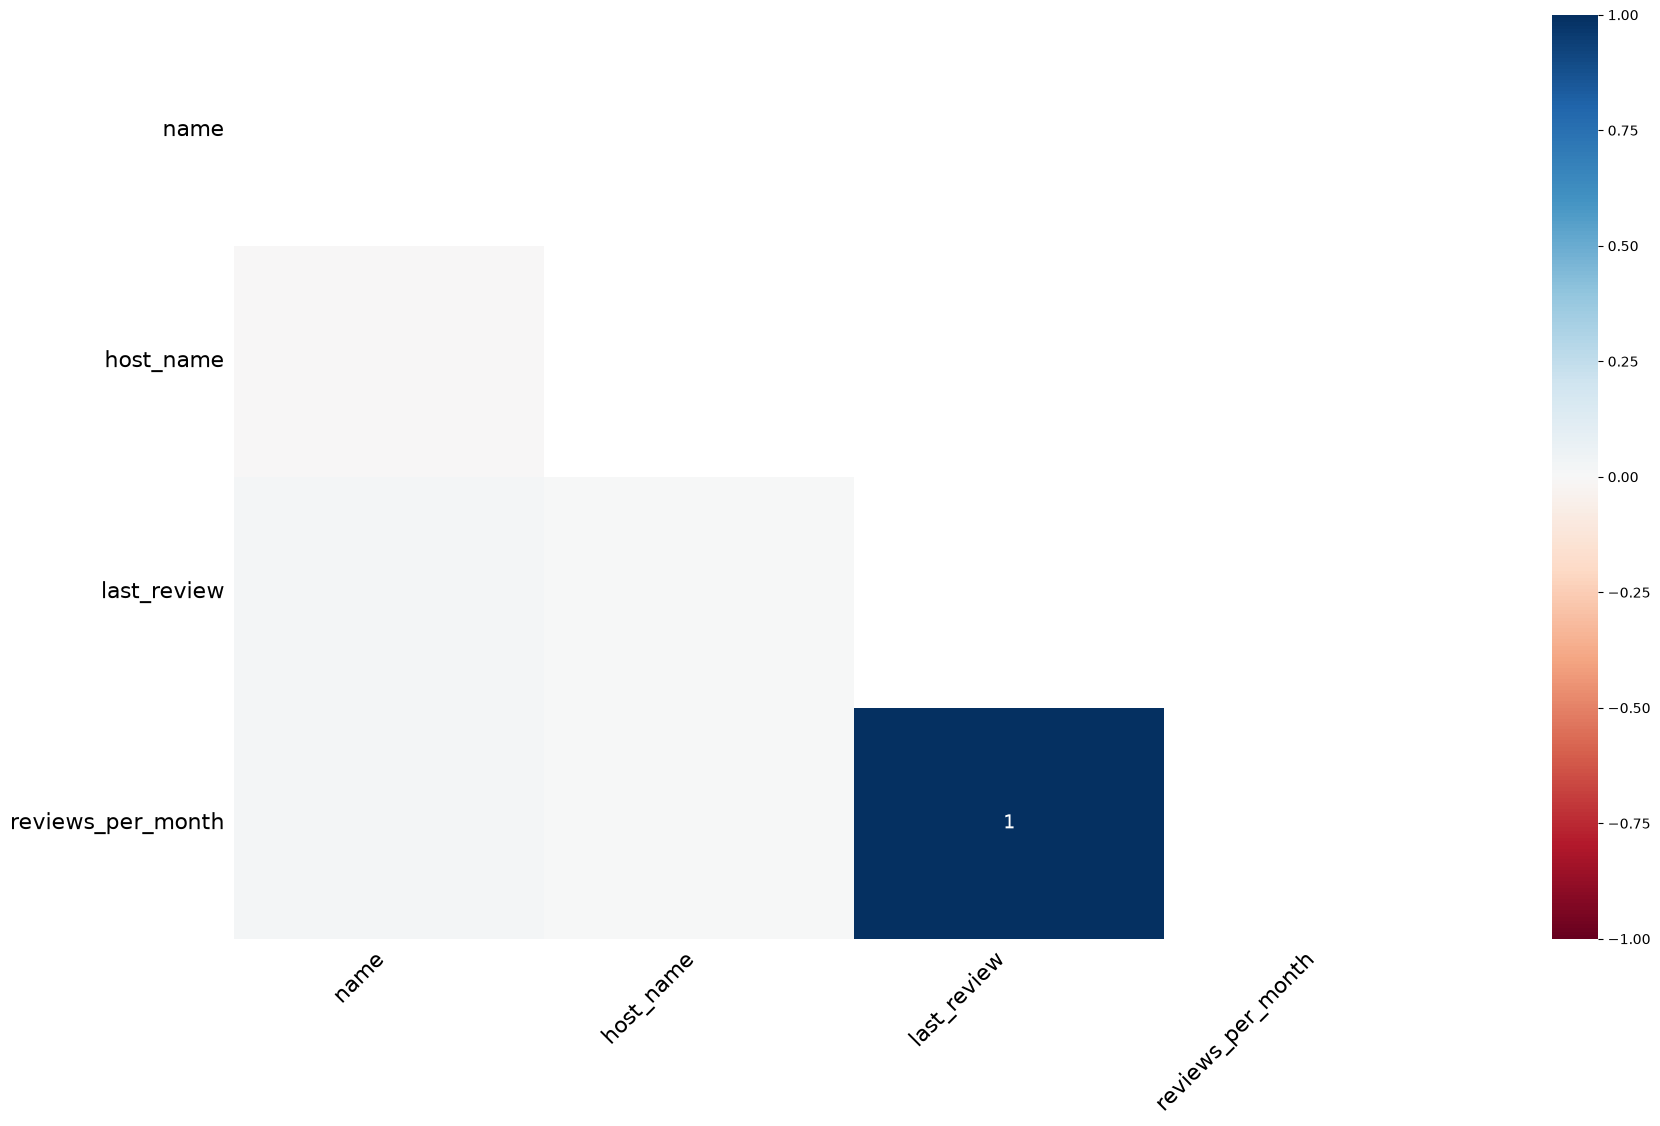

In [46]:
msno.heatmap(df)

In [47]:
zero_reviews = df[df['number_of_reviews'] == 0]
print(f"Rows with 0 reviews: {len(zero_reviews)}")

Rows with 0 reviews: 10052


## Imputing Missing values

In [48]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
# Keep last_review as NaT (missing) — do not fabricate a date
# Optionally, add a boolean flag for clarity in later analysis
df['has_review'] = df['last_review'].notnull()

1. Reviews per month will be imputed with 0 because already proved that number of reviews == 0 so A listing with zero reviews genuinely has zero reviews per month.
2. Unlike reviews_per_month, this isn't a case where the true value is knowable from other columns — a listing that's never been reviewed simply has no last-review date, and that absence is the correct representation of reality 

In [53]:
print(df['reviews_per_month'].isnull().sum())   # should be 0 now
print(df['last_review'].isnull().sum())          # will still show ~10,052 — that's expected and correct
print(df['has_review'].value_counts())           # confirms the split

0
10052
has_review
True     38843
False    10052
Name: count, dtype: int64


In [57]:
df['name'] = df['name'].fillna('Unknown_Listing')
df['host_name'] = df['host_name'].fillna('Unknown_Host')

In [61]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [70]:
df['reviews_per_month'] = pd.to_numeric(df['reviews_per_month'], errors='coerce').round().astype('Int64')
df.reviews_per_month

0        0
1        0
2        0
3        5
4        0
        ..
48895    0
48896    0
48897    0
48898    0
48899    0
Name: reviews_per_month, Length: 48895, dtype: Int64

## Extracting Features & Dropping Columns

In [ ]:
df['id'] = df['id'].rank(method='dense').astype(int)  

id is roughly sequential — earlier ids were likely listed first (proxy for "listing age")

drop the ids column by extracting the features from it in id. The id should show the rank, lower the rank, older the listing. Secondly, dropped the column last_review because number_of_reviews and reviews_per_month already carrying the "review activity" signal, and last_review had the heaviest missingness (~20.6%) of any column plus limited standalone value and we are not doing time-series/recency analysis.

In [93]:
df.info()

<class 'pandas.DataFrame'>
Index: 48895 entries, 0 to 48899
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48895 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48895 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  Int64  
 10  minimum_nights                  48895 non-null  Int64  
 11  number_of_reviews               48895 non-null  int64  
 12  reviews_per_month               48895 non-null  

## Finding unique values and typo mistakes from these 3 columns

In [100]:
print(df.room_type.unique())
print(df.room_type.nunique())
print(df.neighbourhood.unique())
print(df.neighbourhood.nunique())
print(df.neighbourhood_group.unique())
print(df.neighbourhood_group.nunique())

<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str
3
<StringArray>
[        'Kensington',            'Midtown',             'Harlem',
       'Clinton Hill',        'East Harlem',        'Murray Hill',
 'Bedford-Stuyvesant',     'Hell's Kitchen',    'Upper West Side',
          'Chinatown',
 ...
     'Fort Wadsworth',           'Rosebank',          'Unionport',
         'Mill Basin',      'Arden Heights',        'Bull's Head',
           'New Dorp',          'Rossville',       'Breezy Point',
        'Willowbrook']
Length: 221, dtype: str
221
<StringArray>
['Brooklyn', 'Manhattan', 'Broklyn', 'Queens', 'Staten Island', 'Bronx']
Length: 6, dtype: str
6


In [111]:
df.replace({'Broklyn': 'Brooklyn'}, inplace=True)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,1,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0,6,365
1,2,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0,2,355
2,3,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0,1,365
3,4,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,5,1,194
4,5,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48895,48891,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0,2,9
48896,48892,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0,2,36
48897,48893,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0,1,27
48898,48894,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0,6,2


In [106]:
df.neighbourhood_group.value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

New York City comprises 5 boroughs sitting where the Hudson River meets the Atlantic Ocean. But data shows 6 unique values, so we fix the typo mistake of broklyn with brooklyn.

## Top 10 host IDs with the highest number of bookings

In [113]:
df.number_of_reviews.value_counts()

number_of_reviews
0      10052
1       5244
2       3465
3       2520
4       1994
       ...  
417        1
368        1
436        1
310        1
341        1
Name: count, Length: 394, dtype: int64

In [ ]:
# Approach 1: Total number_of_reviews per host (your proxy — cumulative bookings)

top_hosts_by_reviews = (
    df.groupby('host_id')['number_of_reviews']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("Top 10 hosts by total number_of_reviews (proxy for total bookings):")
print(top_hosts_by_reviews)




Top 10 hosts by total number_of_reviews (proxy for total bookings):
host_id
37312959     2273
344035       2205
26432133     2017
35524316     1971
40176101     1818
4734398      1798
16677326     1355
6885157      1346
219517861    1281
23591164     1269
Name: number_of_reviews, dtype: int64


## Top 10 host names with the highest number of bookings

         host_id                       host_name  number_of_reviews                                    label
21316   37312959                            Maya               2273                          Maya (37312959)
1052      344035  Brooklyn&   Breakfast    -Len-               2205  Brooklyn&   Breakfast    -Len- (344035)
18636   26432133                        Danielle               2017                      Danielle (26432133)
20884   35524316                    Yasu & Akiko               1971                  Yasu & Akiko (35524316)
21934   40176101                           Brady               1818                         Brady (40176101)
7365     4734398                              Jj               1798                             Jj (4734398)
14714   16677326                  Alex And Zeena               1355                Alex And Zeena (16677326)
9206     6885157                           Randy               1346                          Randy (6885157)
34646  219517861   

C:\Users\Dell\AppData\Local\Temp\ipykernel_9628\3885273832.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=host_summary, x='number_of_reviews', y='label', palette='viridis')


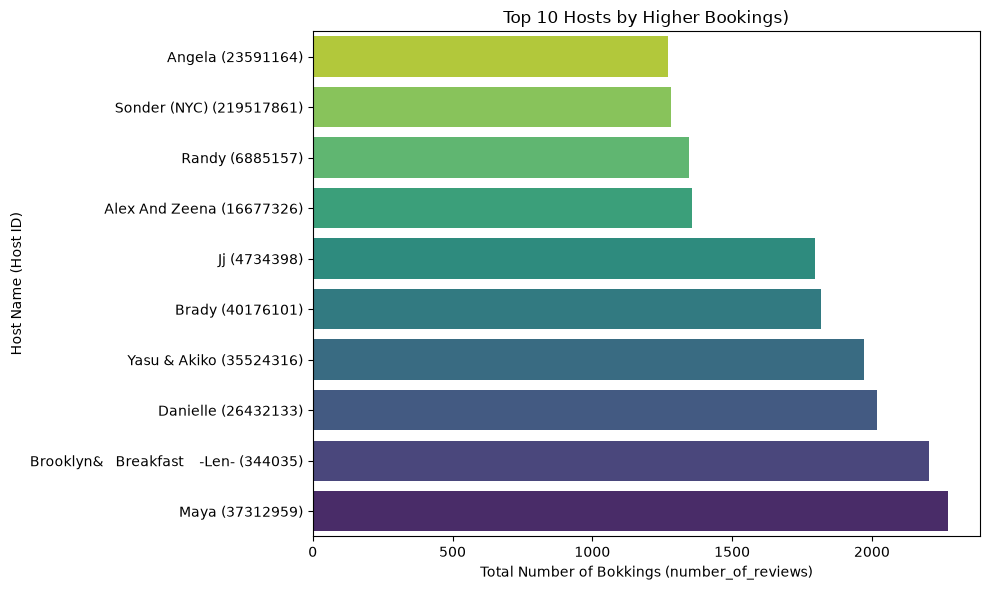

In [ ]:
# Aggregate bookings (number_of_reviews) per host, keeping name for display

host_summary = (
    df.groupby(['host_id', 'host_name'])['number_of_reviews']
    .sum()
    .reset_index()
    .sort_values('number_of_reviews', ascending=False)
    .head(10)
)
host_summary['label'] = host_summary['host_name'] + ' (' + host_summary['host_id'].astype(str) + ')'
print(host_summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=host_summary, x='number_of_reviews', y='label', palette='viridis')
plt.title('Top 10 Hosts by Higher Bookings)')
plt.xlabel('Total Number of Bokkings (number_of_reviews)')
plt.ylabel('Host Name (Host ID)')
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

Host name is not a safe grouping key because multiple hosts have save name like michael so we don't get correct data. Insted, host_ids are unique and we compare it with number of reviews as a proxy for bookings, that's why this data was much more accurate.

## Room type of top host (Having highest bookings)

In [136]:
# Step 1: find the actual host_id of the top host (not just the name)
top_host_id = df.groupby('host_id')['number_of_reviews'].sum().idxmax()

# Step 2: confirm the name matches what you saw on the chart
print(df[df['host_id'] == top_host_id]['host_name'].iloc[0])

# Step 3: now filter safely by the unique id
print(df[df['host_id'] == top_host_id]['room_type'].unique())
print(df[df['host_id'] == top_host_id]['price'].agg(['min', 'max']))

Maya
<StringArray>
['Private room']
Length: 1, dtype: str
min    32
max    46
Name: price, dtype: int64


## How is listing supply split across room types, and how does that split differ by borough?

In [141]:
print(df['room_type'].value_counts(normalize=True) * 100)

print(pd.crosstab(df['neighbourhood_group'], df['room_type']))

room_type
Entire home/apt    51.966459
Private room       45.661111
Shared room         2.372431
Name: proportion, dtype: float64
room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                            379           652           60
Brooklyn                        9559         10132          413
Manhattan                      13199          7982          480
Queens                          2096          3372          198
Staten Island                    176           188            9


## Neighbourhood group with the highest number of bookings

  neighbourhood_group  number_of_reviews
1            Brooklyn             486574
2           Manhattan             454569
3              Queens             156950
0               Bronx              28371
4       Staten Island              11541


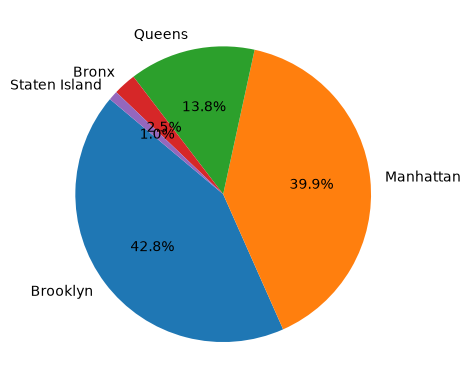

In [ ]:
# Aggregate bookings (number_of_reviews) per neighbourhood group
neighbourhoodgroupbooking_summary = (
    df.groupby(['neighbourhood_group'])['number_of_reviews']
    .sum()
    .reset_index()
    .sort_values('number_of_reviews', ascending=False)
    .head(10)
)
print(neighbourhoodgroupbooking_summary)

plt.pie(data=neighbourhoodgroupbooking_summary, x='number_of_reviews', labels='neighbourhood_group', autopct='%1.1f%%', startangle=140)
plt.show()

pie chart is wrong choice when there are alot of categorical data inside a category so visualization of splitted data cannot showed correctly.

## Average & Second Statistic

In [150]:
df.price.describe()

count       48895.0
mean     152.720728
std      240.154163
min             0.0
25%            69.0
50%           106.0
75%           175.0
max         10000.0
Name: price, dtype: Float64

the average and std has big difference, gives a red flag that price feature contain some sort of outliers and skewed that feature.

## Minimum and maximum prices of the listings,

In [ ]:
print(df.nsmallest(5, 'price'))
print(df.nlargest(5, 'price'))

Bottom 5 cheapest listings:
          id                                               name    host_id     host_name neighbourhood_group       neighbourhood  latitude  longitude        room_type  price  minimum_nights  number_of_reviews  reviews_per_month  calculated_host_listings_count  availability_365
23166  23162  Huge Brooklyn Brownstone Living, Close to it all.    8993084      Kimberly            Brooklyn  Bedford-Stuyvesant  40.69023  -73.95428     Private room      0               4                  1                  0                               4                28
25438  25434      ★Hostel Style Room | Ideal Traveling Buddies★  131697576        Anisha               Bronx     East Morrisania  40.83296  -73.88668     Private room      0               2                 55                  3                               4               127
25639  25635    MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)   15787004  Martial Loft            Brooklyn            Bushwick  40.69467

the price column data was not accurate, it showing listings with 0$ per night which will not possible in real world and if we also compare it with other features like number_of_reviews and minimum nights, similarly a maximum value of 10k$ for private room was not ideal or it maybe an outlier, so inspection needed for it.

## Average prices of different room types

In [163]:
price_summary_by_room = df.groupby('room_type')['price'].agg(
    average_price='mean',
    median_price='median',
    listing_count='count'
).round(2)

print(price_summary_by_room)

                 average_price  median_price  listing_count
room_type                                                  
Entire home/apt         211.79         160.0          25409
Private room             89.78          70.0          22326
Shared room              70.13          45.0           1160


In [169]:
df.groupby('neighbourhood_group')['number_of_reviews'].sum().sort_values(ascending=False)

neighbourhood_group
Brooklyn         486574
Manhattan        454569
Queens           156950
Bronx             28371
Staten Island     11541
Name: number_of_reviews, dtype: int64

## Set and Reset Index

In [170]:
df_copy=df.copy()


In [171]:
df_copy = df_copy.set_index('price')

In [174]:
df_copy = df_copy.reset_index('price')

Moving a column into the index is usually done to make data retrieval faster, data alignment automatic, and plotting cleaner.

## Borough by room type pivot table of median price.

In [178]:
price_pivot = pd.pivot_table(
    df,
    values='price',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='median',
    margins=True,
    margins_name='All'
)

print(price_pivot)

room_type            Entire home/apt  Private room  Shared room    All
neighbourhood_group                                                   
Bronx                          100.0          53.5         40.0   65.0
Brooklyn                       145.0          65.0         36.0   90.0
Manhattan                      191.0          90.0         69.0  150.0
Queens                         120.0          60.0         37.0   75.0
Staten Island                  100.0          50.0         30.0   75.0
All                            160.0          70.0         45.0  106.0


The 'All' row is not a simple average of the borough-level medians because the median is a positional statistic — it depends on the actual sorted order of all underlying data points, not a summary that can be recombined mathematically from subgroup summaries.